#**Classifying Images with Attention**





#*Attention in Vision Models*

Let's work with the MNIST dataset for now

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
x_train = (x_train.astype("float32") / 255.0) - 0.5
x_test = (x_test.astype("float32") / 255.0) - 0.5

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Now let's define our network...

In [10]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# 1. Convolutional Feature Extraction
input_shape = (28, 28, 1)  # Input shape for MNIST
inputs = keras.Input(shape=input_shape)

# We will end up with 64 feature maps, each 7 x 7.
x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(inputs)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(x)
x = layers.MaxPooling2D((2, 2))(x)

# 2. Flatten each feature maps into a vector
# NOTE: We have to shuffle the tensor dimensions from (7, 7, 64) to (64, 7, 7)
# BEFORE reshaping, otherwise the data gets scrambled by tensorflow; it won't flatten the data consistently.
x_permuted = layers.Permute((3, 1, 2))(x)

feature_dim = x_permuted.shape[2] * x_permuted.shape[3] # 7x7 = 49
num_feature_vectors = x_permuted.shape[1] # 64

feature_vectors = layers.Reshape((num_feature_vectors, feature_dim))(x_permuted) # Reshape to (batch_size, 64, 49)

# 3. Multi-Head Attention (Channel Attention, i.e., feature-map attention)
# The 'sequence' here is the set of 64 'flattened' feature maps for a given image.
attention = layers.MultiHeadAttention(num_heads=4, key_dim=feature_dim)(feature_vectors, feature_vectors)

# 4. Skip / residual connection around attention (note that this is typical architecture in attention models)
x = layers.Add()([feature_vectors, attention]) # Add skip connection

# Note that layer normalization normalizes over the embedding dimensions (across dimensions, per sequence)
# This is distinct from BatchNormalization, which normalizes over the batch dimension (across sequences, per dimension).
x = layers.LayerNormalization(epsilon=1e-6)(x)

# 5. MLP - with inverted bottleneck (expand and then contract vectors)
mlp = keras.Sequential([
    layers.Dense(feature_dim * 2, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(feature_dim),
    layers.Dropout(0.2),
])

mlp_output = mlp(x)

# 6. Another additive skip connection around the inverted bottleneck MLP
x = layers.Add()([x, mlp_output])
x = layers.LayerNormalization(epsilon=1e-6)(x)

# 7. Classification Head
x = layers.GlobalAveragePooling1D()(x) # Average across all 64 attended feature maps
outputs = layers.Dense(10, activation="softmax")(x)

# Create the model
model = keras.Model(inputs=inputs, outputs=outputs)

# Compile the model
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# Print model summary
model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 28, 28,    │        320 │ input_layer_6[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 14, 14,    │          0 │ conv2d_6[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 14, 14,    │     18,496 │ max_pooling2d_6[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 7, 7, 64)  │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ permute_3 (Permute) │ (None, 64, 7, 7)  │          0 │ max_pooling2d_7[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_3 (Reshape) │ (None, 64, 49)    │          0 │ permute_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 49)    │     39,053 │ reshape_3[0][0],  │
│ (MultiHeadAttentio… │                   │            │ reshape_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 64, 49)    │          0 │ reshape_3[0][0],  │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 49)    │         98 │ add_6[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_3        │ (None, 64, 49)    │      9,751 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_7 (Add)         │ (None, 64, 49)    │          0 │ layer_normalizat… │
│                     │                   │            │ sequential_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 49)    │         98 │ add_7[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 49)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 10)        │        500 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 68,316 (266.86 KB)

 Trainable params: 68,316 (266.86 KB)

 Non-trainable params: 0 (0.00 B)

And how does it look?

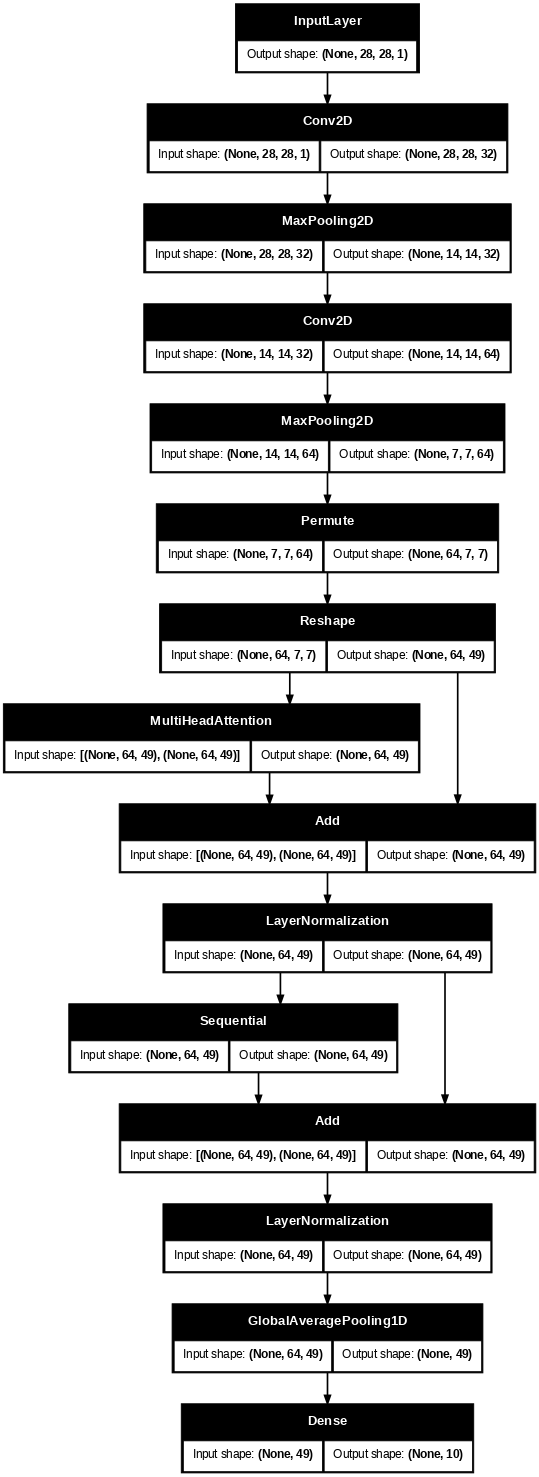

In [6]:
keras.utils.plot_model(model, show_shapes=True, dpi=60)

And we can train the model...

In [11]:
# Train the model
history = model.fit(x_train, y_train, epochs=10, validation_split=0.2, batch_size=32)  # Reduced epochs for demonstration

# Evaluate the model
loss, accuracy = model.evaluate(x_test, y_test)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - accuracy: 0.9145 - loss: 0.2799 - val_accuracy: 0.9607 - val_loss: 0.1280
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9657 - loss: 0.1090 - val_accuracy: 0.9744 - val_loss: 0.0847
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9745 - loss: 0.0809 - val_accuracy: 0.9778 - val_loss: 0.0796
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9790 - loss: 0.0679 - val_accuracy: 0.9822 - val_loss: 0.0594
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9818 - loss: 0.0574 - val_accuracy: 0.9835 - val_loss: 0.0549
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9839 - loss: 0.0517 - val_accuracy: 0.9809 - val_loss: 0.0647
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9851 - loss: 0.0468 - val_accuracy: 0.9837 - val_loss: 0.0574
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9864 - loss: 0.0421 -

Plot performance over training...

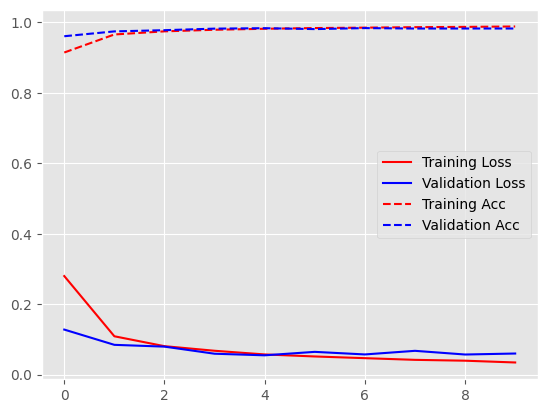

In [12]:
import matplotlib.pyplot as plt
plt.style.use('ggplot')

plt.plot(history.history['loss'],c="r")
plt.plot(history.history['val_loss'],c="b")
plt.plot(history.history['accuracy'],c="r",linestyle="--")
plt.plot(history.history['val_accuracy'],c="b",linestyle="--")
plt.legend(['Training Loss','Validation Loss','Training Acc','Validation Acc'])
plt.show()